# CIFAR-10 CNN Training (TensorFlow / Keras)
- Loads from `cifar10_preprocessed.npz`
- 75K images (50K + 25K augmented)
- Denoised + CLAHE + Sharpened + Augmented + Cutout
- 100 Epochs with LR Scheduler + Early Stopping

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import time

if os.path.basename(os.getcwd()) == 'Model':
    os.chdir('..')
if os.path.basename(os.getcwd()) == 'TensorFlow':
    os.chdir('..')

## 1. Setup Device

In [2]:
print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')
print(f'Built with CUDA: {tf.test.is_built_with_cuda()}')

TensorFlow version: 2.21.0
GPUs available: []
Built with CUDA: False


## 2. Load Preprocessed Data

In [3]:
data = np.load('TensorFlow/Preprocessing/cifar10_preprocessed.npz')

X_train = data['X_train'].astype(np.float32)
X_val   = data['X_val'].astype(np.float32)
X_test  = data['X_test'].astype(np.float32)
y_train = data['y_train'].astype(np.int64)
y_val   = data['y_val'].astype(np.int64)
y_test  = data['y_test'].astype(np.int64)
label_names = list(data['label_names'])

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (67500, 32, 32, 3) | Val: (7500, 32, 32, 3) | Test: (10000, 32, 32, 3)


## 3. Define CNN Model

In [4]:
def build_cnn():
    inputs = keras.Input(shape=(32, 32, 3))

    # Block 1: 32x32 -> 16x16
    x = layers.Conv2D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    # Block 2: 16x16 -> 8x8
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.5)(x)

    # Block 3: 8x8 -> 4x4
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.5)(x)

    # Classifier
    x = layers.Flatten()(x)
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_cnn()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 3,253,834 (12.41 MB)

 Trainable params: 3,251,018 (12.40 MB)

 Non-trainable params: 2,816 (11.00 KB)

## 4. Compile & Train (100 Epochs)

In [5]:
EPOCHS = 100
BATCH_SIZE = 128
MODEL_PATH = 'TensorFlow/Model/best_cnn_model.h5'

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.01,
    decay_steps=EPOCHS * (len(X_train) // BATCH_SIZE),
)

optimizer = keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

print(f'Training for {EPOCHS} epochs (early stopping: patience=10)...')
start = time.time()

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining completed in {time.time()-start:.1f}s')

Training for 100 epochs (early stopping: patience=10)...
Epoch 1/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.2887 - loss: 2.1195
Epoch 1: val_accuracy improved from None to 0.37813, saving model to TensorFlow/Model/best_cnn_model.h5



Epoch 1: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 214s 404ms/step - accuracy: 0.3696 - loss: 1.7692 - val_accuracy: 0.3781 - val_loss: 1.9425
Epoch 2/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.4865 - loss: 1.4103
Epoch 2: val_accuracy improved from 0.37813 to 0.50773, saving model to TensorFlow/Model/best_cnn_model.h5



Epoch 2: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 224s 425ms/step - accuracy: 0.5024 - loss: 1.3652 - val_accuracy: 0.5077 - val_loss: 1.3867
Epoch 3/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.5582 - loss: 1.2270
Epoch 3: val_accuracy improved from 0.50773 to 0.52693, saving model to TensorFlow/Model/best_cnn_model.h5



Epoch 3: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 249s 473ms/step - accuracy: 0.5677 - loss: 1.2031 - val_accuracy: 0.5269 - val_loss: 1.3410
Epoch 4/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.6024 - loss: 1.1066
Epoch 4: val_accuracy improved from 0.52693 to 0.58427, saving model to TensorFlow/Model/best_cnn_model.h5



Epoch 4: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 250s 473ms/step - accuracy: 0.6105 - loss: 1.0885 - val_accuracy: 0.5843 - val_loss: 1.1801
Epoch 5/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.6343 - loss: 1.0221
Epoch 5: val_accuracy improved from 0.58427 to 0.65547, saving model to TensorFlow/Model/best_cnn_model.h5


...


Epoch 74: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 316s 598ms/step - accuracy: 0.9205 - loss: 0.2200 - val_accuracy: 0.8728 - val_loss: 0.4177
Epoch 75/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9224 - loss: 0.2188
Epoch 75: val_accuracy did not improve from 0.87280
528/528 ━━━━━━━━━━━━━━━━━━━━ 787s 1s/step - accuracy: 0.9223 - loss: 0.2174 - val_accuracy: 0.8635 - val_loss: 0.4602
Epoch 76/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9231 - loss: 0.2129
Epoch 76: val_accuracy did not improve from 0.87280
528/528 ━━━━━━━━━━━━━━━━━━━━ 252s 478ms/step - accuracy: 0.9226 - loss: 0.2167 - val_accuracy: 0.8696 - val_loss: 0.4318
Epoch 77/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9221 - loss: 0.2141
Epoch 77: val_accuracy did not improve from 0.87280
528/528 ━━━━━━━━━━━━━━━━━━━━ 1039s 2s/step - accuracy: 0.9212 - loss: 0.2171 - val_accuracy: 0.8687 - val_loss: 0.4337
Epoch 78/100
528/528 ━━━━━━━━━


Epoch 79: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 254s 482ms/step - accuracy: 0.9232 - loss: 0.2135 - val_accuracy: 0.8737 - val_loss: 0.4192
Epoch 80/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9256 - loss: 0.2087
Epoch 80: val_accuracy improved from 0.87373 to 0.87400, saving model to TensorFlow/Model/best_cnn_model.h5



Epoch 80: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 274s 519ms/step - accuracy: 0.9243 - loss: 0.2107 - val_accuracy: 0.8740 - val_loss: 0.4150
Epoch 81/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.9271 - loss: 0.2074
Epoch 81: val_accuracy did not improve from 0.87400
528/528 ━━━━━━━━━━━━━━━━━━━━ 281s 533ms/step - accuracy: 0.9273 - loss: 0.2069 - val_accuracy: 0.8735 - val_loss: 0.4181
Epoch 82/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.9254 - loss: 0.2040
Epoch 82: val_accuracy did not improve from 0.87400
528/528 ━━━━━━━━━━━━━━━━━━━━ 281s 532ms/step - accuracy: 0.9260 - loss: 0.2057 - val_accuracy: 0.8712 - val_loss: 0.4246
Epoch 83/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.9296 - loss: 0.2000
Epoch 83: val_accuracy did not improve from 0.87400
528/528 ━━━━━━━━━━━━━━━━━━━━ 282s 534ms/step - accuracy: 0.9281 - loss: 0.2017 - val_accuracy: 0.8729 - val_loss: 0.4286
Epoch 84/100
528/52


Epoch 89: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 283s 536ms/step - accuracy: 0.9297 - loss: 0.1979 - val_accuracy: 0.8752 - val_loss: 0.4231
Epoch 90/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.9296 - loss: 0.1986
Epoch 90: val_accuracy did not improve from 0.87520
528/528 ━━━━━━━━━━━━━━━━━━━━ 285s 540ms/step - accuracy: 0.9307 - loss: 0.1947 - val_accuracy: 0.8749 - val_loss: 0.4256
Epoch 91/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.9298 - loss: 0.1939
Epoch 91: val_accuracy did not improve from 0.87520
528/528 ━━━━━━━━━━━━━━━━━━━━ 285s 540ms/step - accuracy: 0.9296 - loss: 0.1967 - val_accuracy: 0.8752 - val_loss: 0.4238
Epoch 92/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.9303 - loss: 0.1972
Epoch 92: val_accuracy improved from 0.87520 to 0.87693, saving model to TensorFlow/Model/best_cnn_model.h5



Epoch 92: finished saving model to TensorFlow/Model/best_cnn_model.h5
528/528 ━━━━━━━━━━━━━━━━━━━━ 284s 537ms/step - accuracy: 0.9297 - loss: 0.1979 - val_accuracy: 0.8769 - val_loss: 0.4211
Epoch 93/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9291 - loss: 0.1974
Epoch 93: val_accuracy did not improve from 0.87693
528/528 ━━━━━━━━━━━━━━━━━━━━ 291s 551ms/step - accuracy: 0.9294 - loss: 0.1980 - val_accuracy: 0.8745 - val_loss: 0.4280
Epoch 94/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.9293 - loss: 0.1987
Epoch 94: val_accuracy did not improve from 0.87693
528/528 ━━━━━━━━━━━━━━━━━━━━ 280s 530ms/step - accuracy: 0.9313 - loss: 0.1941 - val_accuracy: 0.8751 - val_loss: 0.4250
Epoch 95/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.9296 - loss: 0.1952
Epoch 95: val_accuracy did not improve from 0.87693
528/528 ━━━━━━━━━━━━━━━━━━━━ 283s 536ms/step - accuracy: 0.9307 - loss: 0.1932 - val_accuracy: 0.8751 - val_loss: 0.4229
Epoch 96/100
528/52

## 5. Test Set Evaluation

In [6]:
model = keras.models.load_model(MODEL_PATH)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
y_true = y_test

print(f'\nPer-Class Accuracy:')
for i, name in enumerate(label_names):
    mask = y_true == i
    if mask.sum() > 0:
        print(f'  {name:<12s}: {(y_pred[mask] == i).mean()*100:.1f}%')

Test Accuracy: 86.89%

Per-Class Accuracy:
  airplane    : 86.5%
  automobile  : 93.2%
  bird        : 81.5%
  cat         : 61.0%
  deer        : 90.0%
  dog         : 82.9%
  frog        : 95.0%
  horse       : 90.1%
  ship        : 95.2%
  truck       : 93.5%


## 6. Classification Report

In [7]:
print(classification_report(y_true, y_pred, target_names=label_names))

              precision    recall  f1-score   support

    airplane       0.91      0.86      0.89      1000
  automobile       0.95      0.93      0.94      1000
        bird       0.85      0.81      0.83      1000
         cat       0.83      0.61      0.70      1000
        deer       0.80      0.90      0.85      1000
         dog       0.79      0.83      0.81      1000
        frog       0.82      0.95      0.88      1000
       horse       0.93      0.90      0.91      1000
        ship       0.91      0.95      0.93      1000
       truck       0.92      0.94      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



## 7. Training Curves

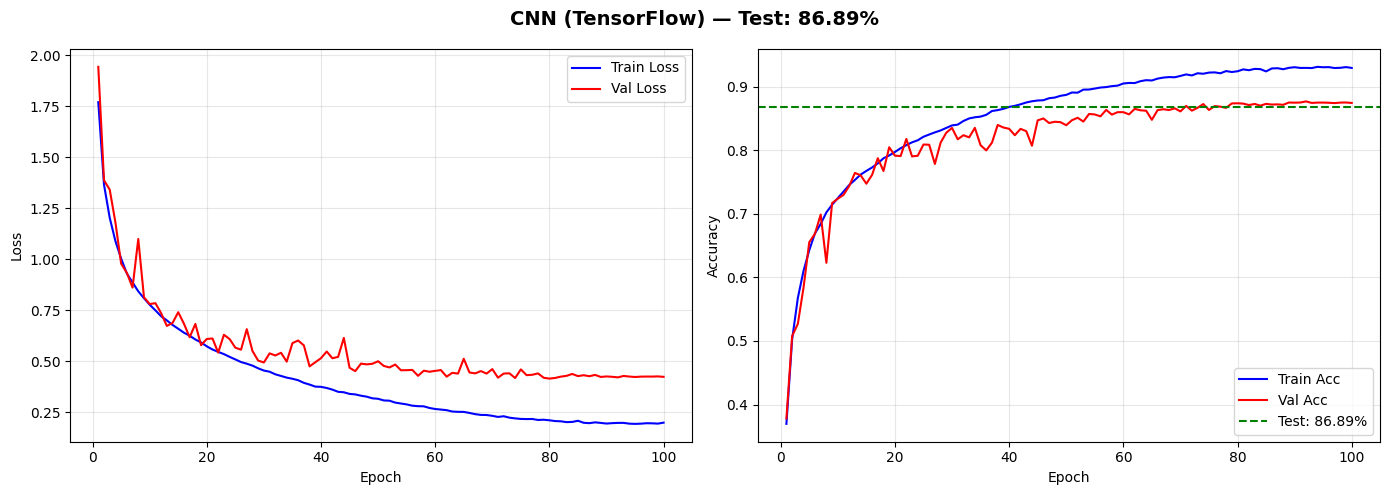

In [8]:
actual_epochs = len(history.history['loss'])
epochs_range = range(1, actual_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, history.history['loss'], 'b-', label='Train Loss')
ax1.plot(epochs_range, history.history['val_loss'], 'r-', label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history.history['accuracy'], 'b-', label='Train Acc')
ax2.plot(epochs_range, history.history['val_accuracy'], 'r-', label='Val Acc')
ax2.axhline(y=test_acc, color='green', linestyle='--', label=f'Test: {test_acc*100:.2f}%')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f'CNN (TensorFlow) — Test: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('TensorFlow/Figure/training_curves_cnn.png', dpi=150)
plt.show()

## 8. Confusion Matrix

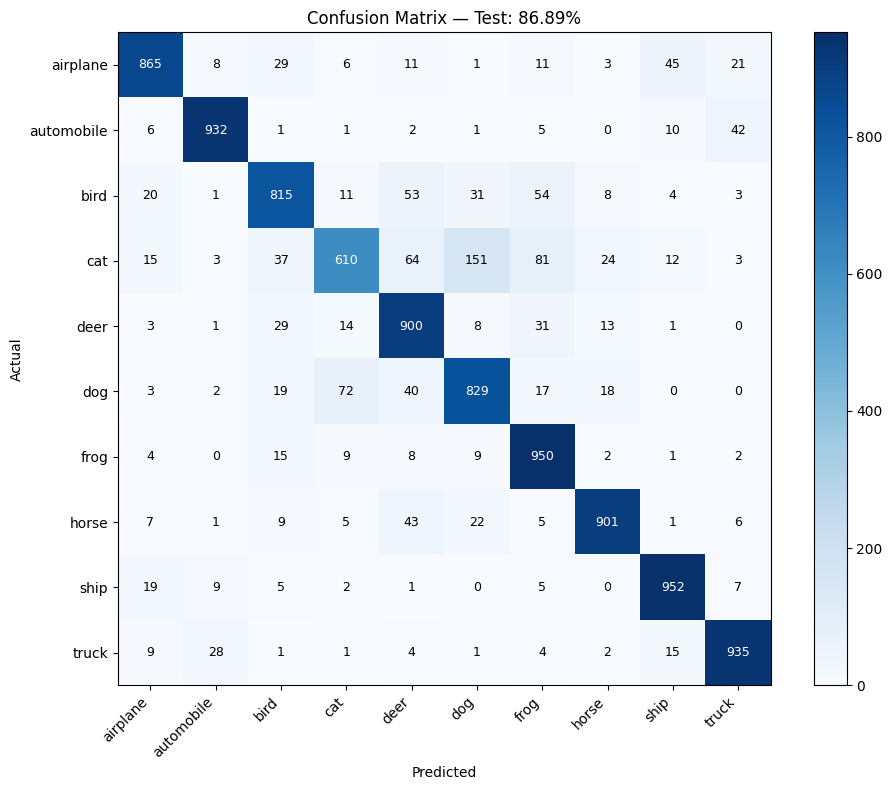

In [9]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(label_names, rotation=45, ha='right'); ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — Test: {test_acc*100:.2f}%')
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)
plt.colorbar(im); plt.tight_layout()
plt.savefig('TensorFlow/Figure/confusion_matrix_cnn.png', dpi=150)
plt.show()

## 9. Sample Predictions

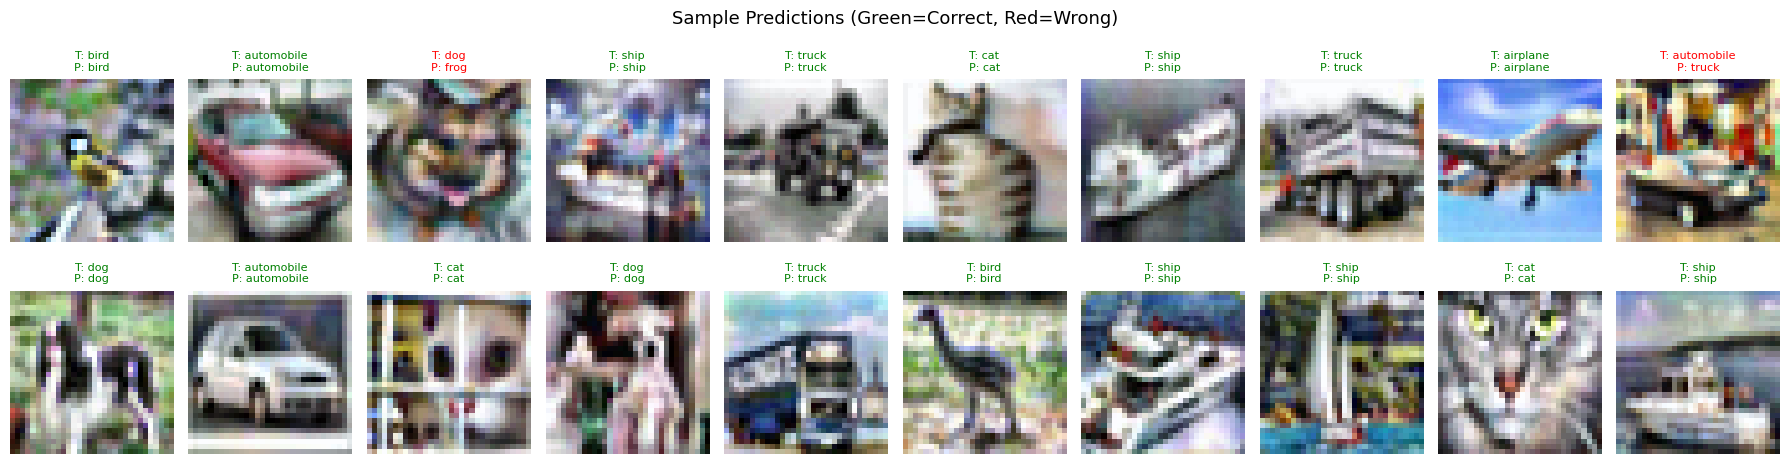

In [10]:
test_display = (X_test - X_test.min()) / (X_test.max() - X_test.min())

np.random.seed(42)
indices = np.random.choice(len(y_true), 20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 5))
for i, idx in enumerate(indices):
    ax = axes[i // 10, i % 10]
    ax.imshow(test_display[idx])
    color = 'green' if y_true[idx] == y_pred[idx] else 'red'
    ax.set_title(f'T: {label_names[y_true[idx]]}\nP: {label_names[y_pred[idx]]}', fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('TensorFlow/Figure/sample_predictions_cnn.png', dpi=150)
plt.show()

## Summary

| Setting | Value |
|---|---|
| Data | `cifar10_preprocessed.npz` |
| Total Images | 75K (50K + 25K augmented) |
| Preprocessing | Denoise + CLAHE + Sharpen |
| Augmentation | Flip + Rotation + Crop + Brightness + Cutout |
| Resolution | 32×32 (original) |
| Split | 67.5K train / 7.5K val / 10K test |
| Framework | **TensorFlow / Keras** |
| Model | CNN (3 conv blocks) |
| Parameters | ~3.25M |
| Epochs | 100 (with early stopping, patience=10) |
| Dropout | 0.4 / 0.5 / 0.5 / 0.6 |
| Loss | SparseCategoricalCrossentropy |
| Optimizer | SGD (lr=0.01, momentum=0.9) |
| Scheduler | CosineDecay |